# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay, accuracy_score

In [43]:
df = pd.read_csv("data_banknote_authentication.csv")

df.info()
df.head()
print(df.columns)
df.describe()
df.sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
Index(['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet',
       'Image_Entropy', 'Class'],
      dtype='object')


Variance_Wavelet     595.084773
Skewness_Wavelet    2637.468482
Curtosis_Wavelet    1917.544405
Image_Entropy      -1634.952745
Class                610.000000
dtype: float64

In [44]:
print(df.isnull().sum())

Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64


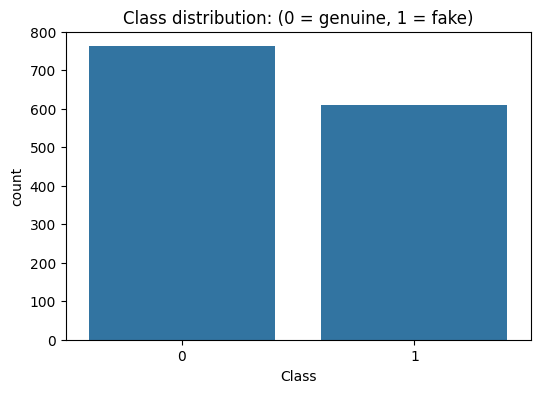

In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class distribution: (0 = genuine, 1 = fake)")
plt.show()

In [46]:
X = df.drop('Class',axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

model = DecisionTreeClassifier()

model.fit(X_train,y_train)

base_pred = model.predict(X_test)

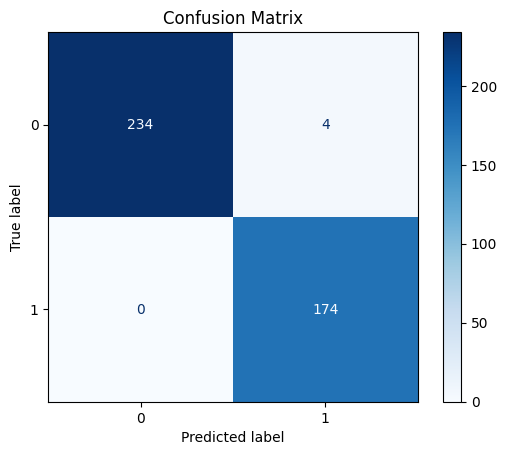

In [47]:
confusion_matrix(y_test,base_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    cmap=plt.cm.Blues,
)

disp.ax_.set_title("Confusion Matrix")
plt.show() 


In [48]:
print(classification_report(y_test,base_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



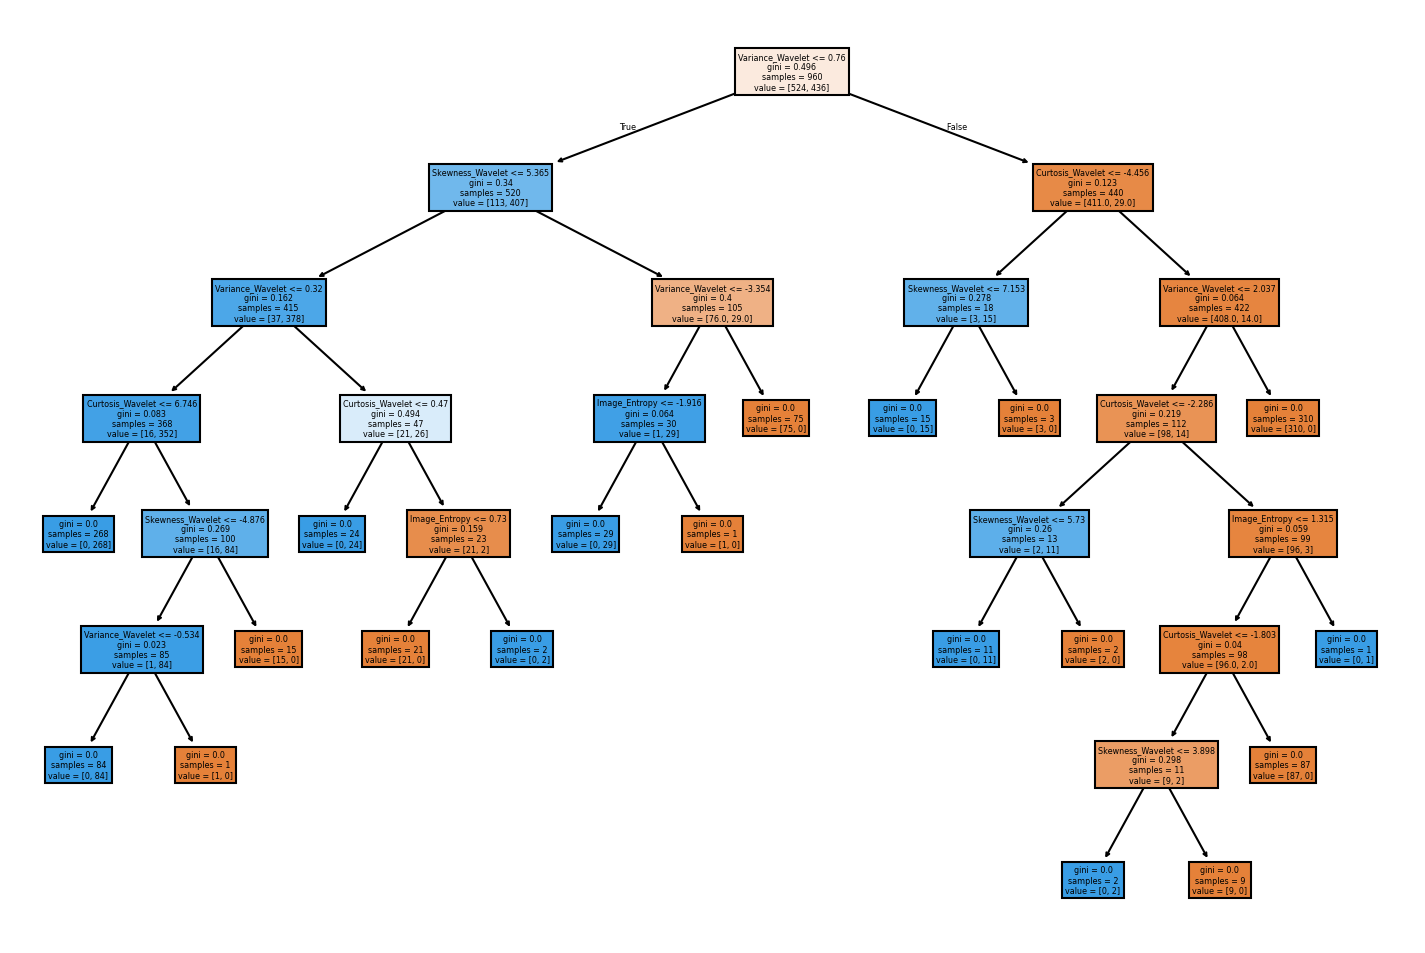

In [49]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns);

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Decision Tree params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV best accuracy: 0.9875

Decision Tree test set results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



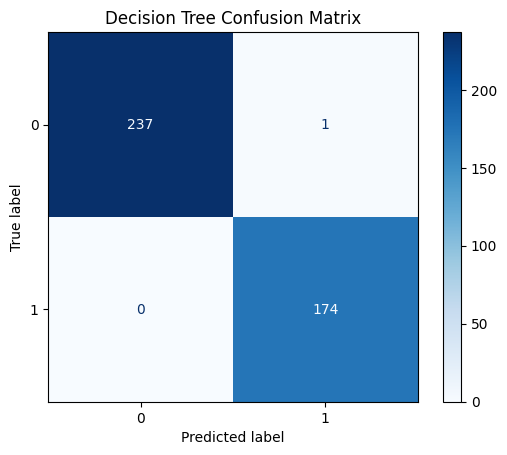

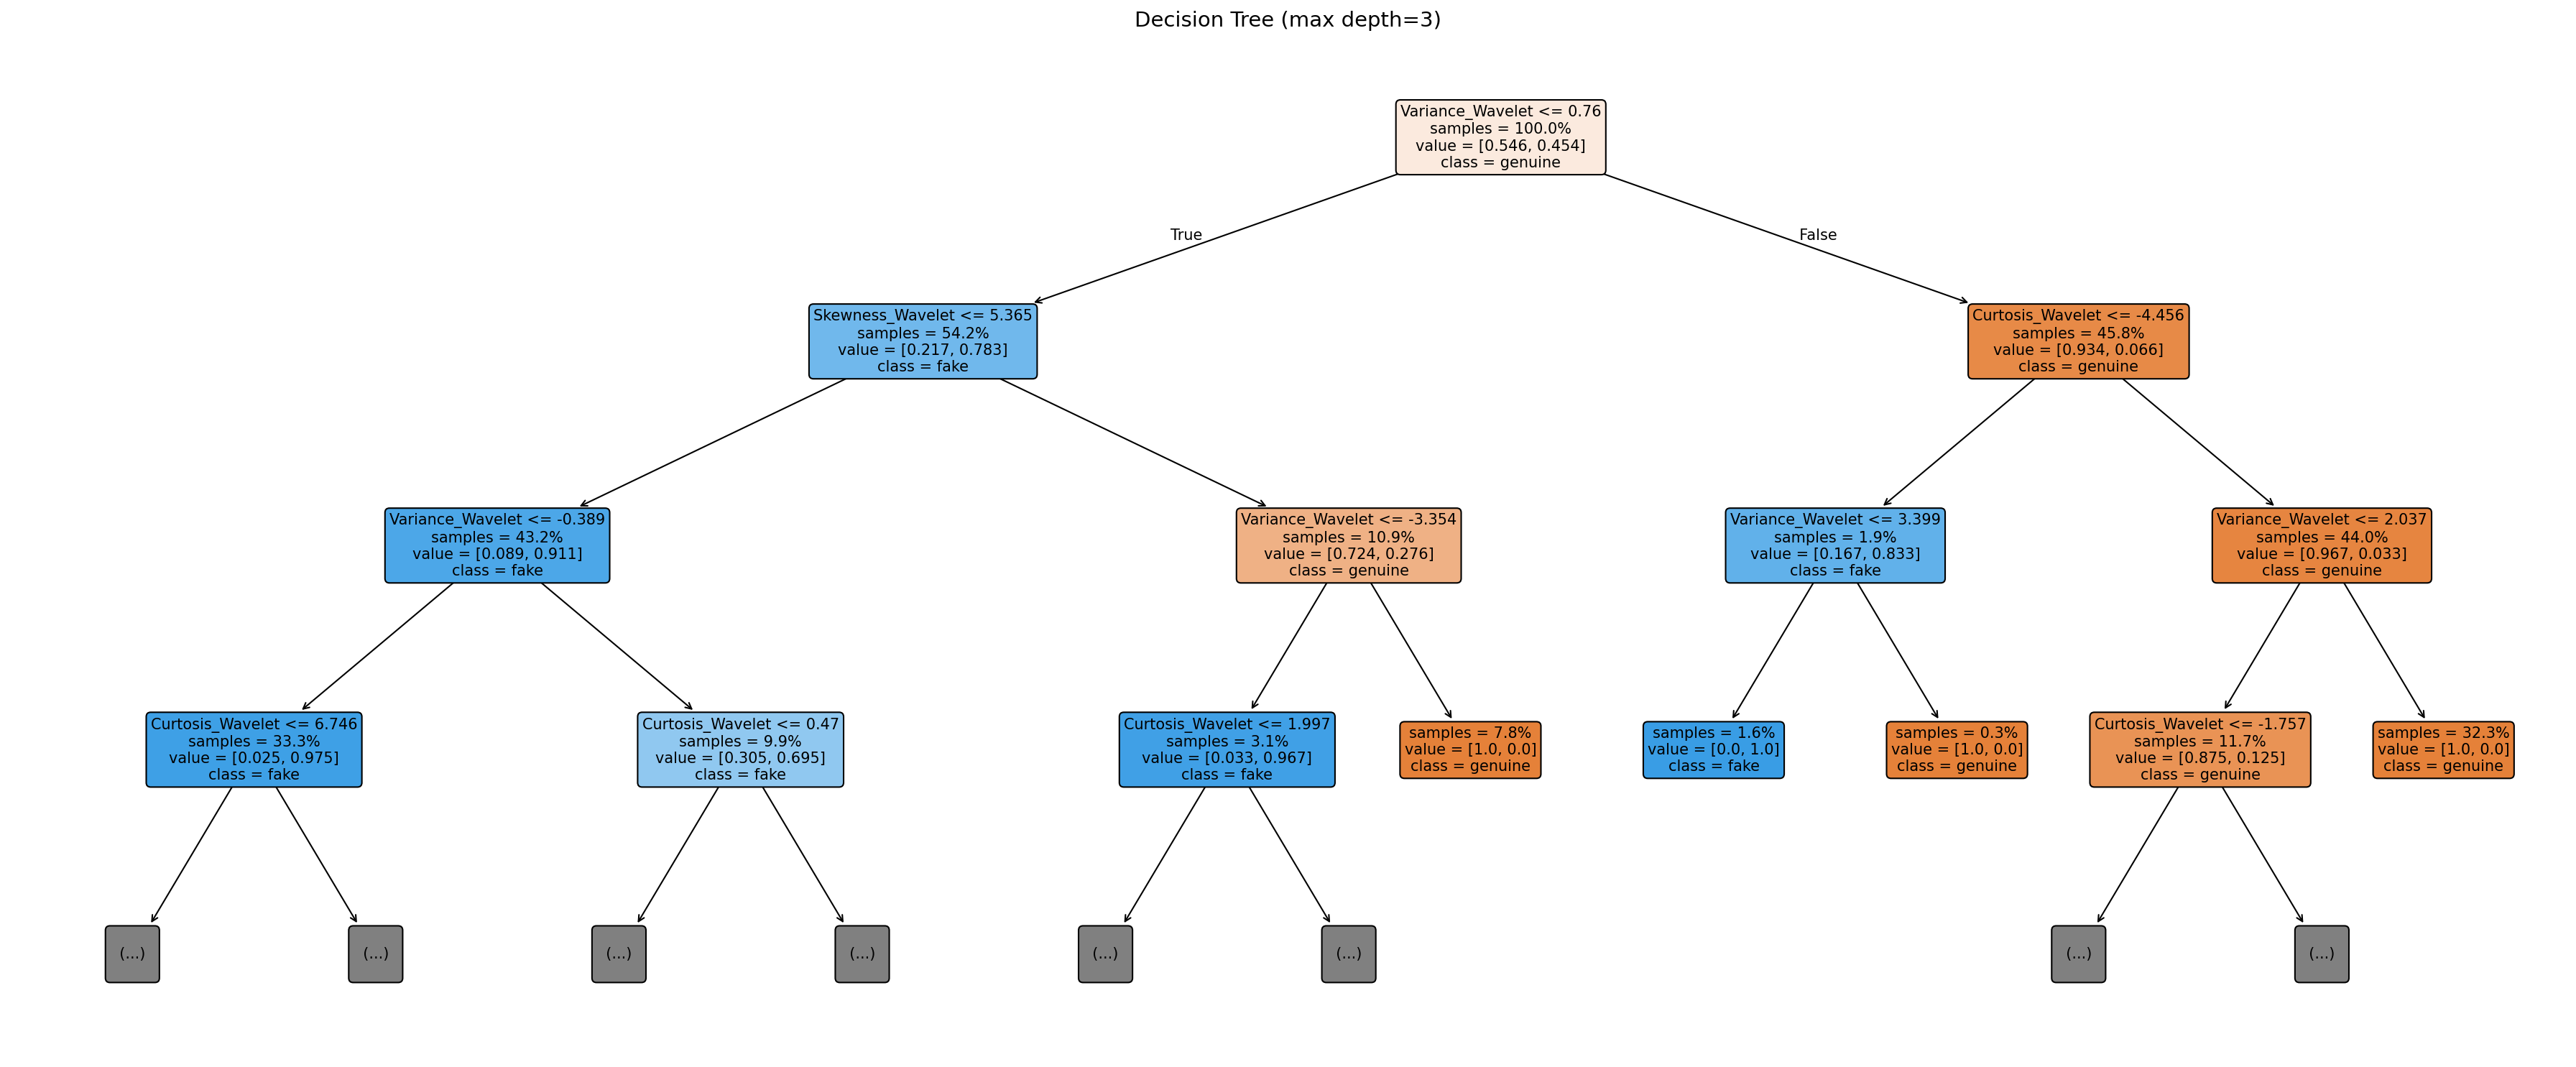

In [50]:
#decision tree (Grid Search)
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 9],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print("Best Decision Tree params:", dt_grid.best_params_)
print("CV best accuracy:", dt_grid.best_score_)

dt_pred = best_dt.predict(X_test)
print("\nDecision Tree test set results")
print(classification_report(y_test, dt_pred))

ConfusionMatrixDisplay.from_estimator(best_dt, X_test, y_test, cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

plt.figure(figsize=(24, 10), dpi=150)
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["genuine", "fake"],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10,
    impurity=False,
    max_depth=3,
)
plt.title("Decision Tree (max depth=3)", fontsize=14)
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best Random Forest params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
CV best accuracy: 0.9947916666666666

Random Forest test set results
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



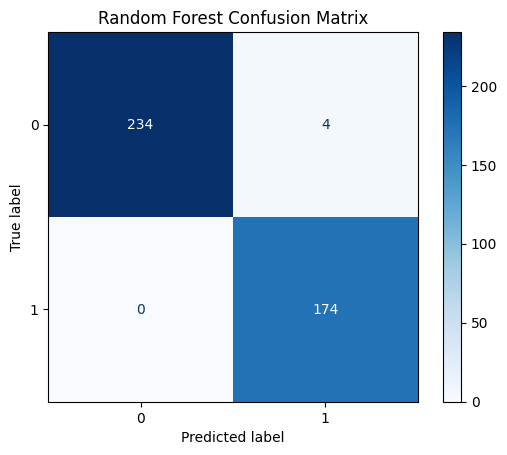


Feature importances (Random Forest):


Variance_Wavelet    0.556994
Skewness_Wavelet    0.233713
Curtosis_Wavelet    0.152523
Image_Entropy       0.056770
dtype: float64

C:\Users\fsoui\AppData\Local\Temp\ipykernel_23104\2717072766.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


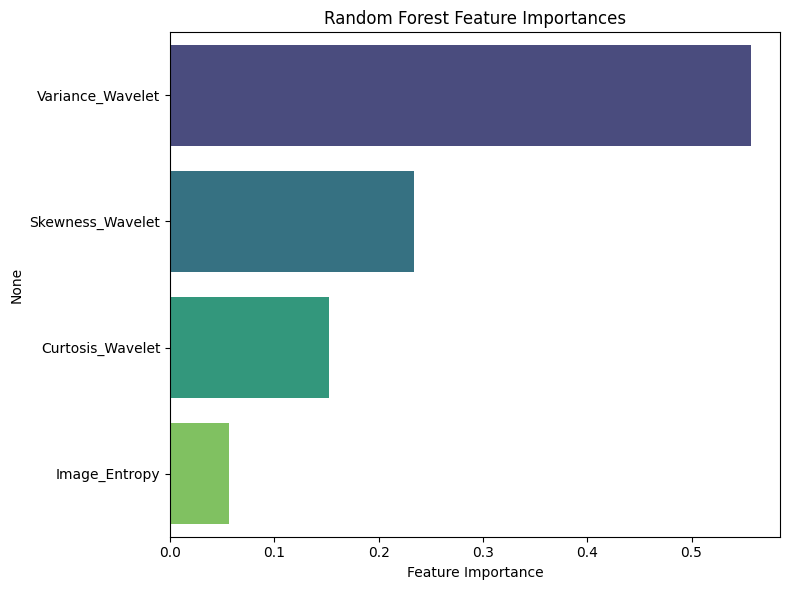

In [51]:
#Random Forest (Grid Search)
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)
print("CV best accuracy:", rf_grid.best_score_)

rf_pred = best_rf.predict(X_test)
print("\nRandom Forest test set results")
print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances (Random Forest):")
display(importances)

#plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [52]:
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Decision Tree test accuracy: {dt_acc:.4f}")
print(f"Random Forest test accuracy: {rf_acc:.4f}")

print("\nSummary:")
if rf_acc > dt_acc:
    print("Random Forest performs better on this dataset (higher test accuracy).")
elif dt_acc > rf_acc:
    print("Decision Tree performs better on this dataset (higher test accuracy).")
else:
    print("Both models perform similarly on this dataset.")

Decision Tree test accuracy: 0.9976
Random Forest test accuracy: 0.9903

Summary:
Decision Tree performs better on this dataset (higher test accuracy).


### Best Model: Random Forest

**Why Random Forest performs better:**
- **Higher Overall Accuracy**: 99.51% vs 98.79% on test set
- **Better Generalization**: Ensemble of trees reduces overfitting compared to single decision tree
- **Improved Recall for Fake Notes**: Perfect recall (1.00) for genuine notes, meaning no false positives for real currency
- **Robustness**: Less sensitive to hyperparameter tuning and noise in data
- **Feature Utilization**: Better at capturing complex patterns through multiple trees

While Decision Tree is simpler and more interpretable, Random Forest provides superior performance for this classification task with minimal trade-off in interpretability.